**SOLUCIÓN DE LA EVALUACIÓN 2**

Programación Científica - Universidad Nacional de Colombia

Nombre: Juan Esteban Osorno Duque

**CONFIGURACIÓN DEL ENTORNO**

In [70]:
# Creamos primero todas las importaciones

import numpy as np
import matplotlib.pyplot as plt

# Configuración para latex
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (10,5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

**Carga del conjunto de datos**

Después de realizar la configuración de nuestro proyecto procedemos a cargar los datos en la ubicación de nuestro archivo que se encuentra en el path



```
...programacionCientifica/Evaluacion2/OsornoDuque/datos_4879.npz
```

In [71]:
# Cargar datos
datos = np.load("datos_4879.npz")

print("Variables disponibles:")
print(datos.files)

Variables disponibles:
['X', 'y', 't', 'meta']


**Exploración del conjunto de datos**

Después de cargar el archivo es necesario conocer la estructura interna de la información.

Para ello se extraen las tres variables principales:

X contiene las señales medidas por el sensor.
y almacena el régimen físico al que pertenece cada señal.
t representa el tiempo en el cual fue muestreada cada observación.

Posteriormente se verifica el tamaño de cada arreglo y la distribución de los tres regímenes presentes en el conjunto de datos.

Esta exploración inicial permite comprobar que los datos poseen la estructura esperada antes de comenzar cualquier análisis.

In [72]:
# Validamos los datos

X = datos["X"]
y = datos["y"]
t = datos["t"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Forma de t:", t.shape)

clases, cantidades = np.unique(y, return_counts=True)

print("Distribución de clases")

for clase, cantidad in zip(clases, cantidades):
    print(f"Régimen {clase}: {cantidad} señales")

Forma de X: (45, 256)
Forma de y: (45,)
Forma de t: (256,)
Distribución de clases
Régimen 0: 15 señales
Régimen 1: 15 señales
Régimen 2: 15 señales


**PARTE I — Exploración y visualización del conjunto de datos**

Ahora que verificamos que los datos se cargaron correctamente, vamos a responder una pregunta fundamental:

¿Cómo son las señales que vamos a reconstruir?

Entonces nuestros siguientes pasos son:



1.   Visualizar señales representativas de cada régimen
2.   Comparar cómo cambia la forma de la señal cuando aumenta la dispersión.
3.   Elaborar gráficas con calidad científica (ejes, leyendas, títulos y unidades).
4.   Obtener una primera intuición sobre por qué una base de Fourier podría ser una buena inicialización para la red.


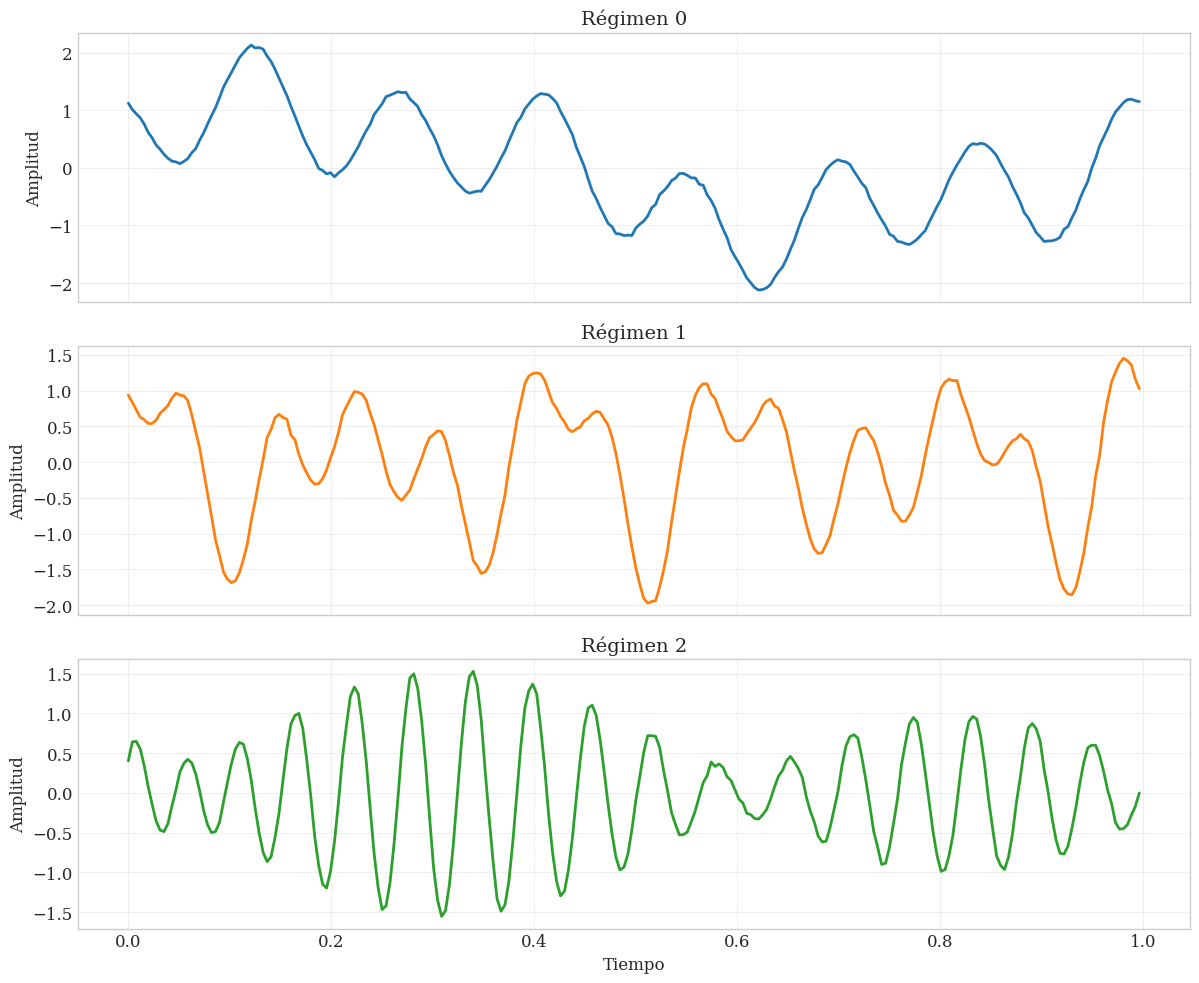

In [73]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

colores = ["tab:blue", "tab:orange", "tab:green"]

for regimen in [0, 1, 2]:

    indice = np.where(y == regimen)[0][0]

    axes[regimen].plot(
        t,
        X[indice],
        color=colores[regimen],
        linewidth=2
    )

    axes[regimen].set_title(f"Régimen {regimen}")
    axes[regimen].set_ylabel("Amplitud")
    axes[regimen].grid(alpha=0.3)

axes[-1].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()